# Problem 3: Understanding Type II Error in t-Tests

## Introduction

In hypothesis testing, we face two types of errors:
- **Type I Error (α)**: Rejecting the null hypothesis when it is actually true (false positive)
- **Type II Error (β)**: Failing to reject the null hypothesis when it is actually false (false negative)

**Statistical Power** is defined as **1 - β**, representing the probability of correctly rejecting a false null hypothesis.

In this analysis, we investigate how the **Type II error rate changes** as the true difference between two populations increases. We simulate independent samples t-tests with varying effect sizes to understand:
1. How likely we are to miss a real difference (Type II error)
2. How statistical power increases with effect size
3. What sample sizes and effect sizes are needed for adequate power

This has practical implications for experimental design: larger effect sizes are easier to detect, while small effects may require much larger sample sizes to achieve acceptable power (typically 80%).

In [1]:
# Imports
import numpy as np
from scipy import stats
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print('matplotlib not installed. Install with: pip install matplotlib')

In [2]:
# Simulation parameters
MEAN_DIFFS = np.arange(0, 1.1, 0.1)  # d = 0, 0.1, 0.2, ..., 1.0
N_SIMULATIONS = 1000                  # number of repetitions per d
SAMPLE_SIZE = 100                     # size of each sample
ALPHA = 0.05                          # significance level
SEED = 2025                           # for reproducibility

print(f'Mean differences to test: {MEAN_DIFFS}')
print(f'Simulations per difference: {N_SIMULATIONS}')
print(f'Sample size: {SAMPLE_SIZE}')
print(f'Significance level: {ALPHA}')

Mean differences to test: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Simulations per difference: 1000
Sample size: 100
Significance level: 0.05


In [3]:
# Run simulations
rng = np.random.default_rng(SEED)
type2_error_rates = []

for d in MEAN_DIFFS:
    non_rejections = 0
    
    for _ in range(N_SIMULATIONS):
        # Draw two samples
        sample1 = rng.normal(loc=0, scale=1, size=SAMPLE_SIZE)
        sample2 = rng.normal(loc=d, scale=1, size=SAMPLE_SIZE)
        
        # Perform independent samples t-test
        t_stat, p_value = stats.ttest_ind(sample1, sample2)
        
        # Check if null hypothesis is NOT rejected (p >= alpha)
        if p_value >= ALPHA:
            non_rejections += 1
    
    # Calculate proportion of non-rejections
    type2_rate = non_rejections / N_SIMULATIONS
    type2_error_rates.append(type2_rate)
    print(f'd = {d:.1f}: Type II error rate = {type2_rate:.3f}')

type2_error_rates = np.array(type2_error_rates)

d = 0.0: Type II error rate = 0.944
d = 0.1: Type II error rate = 0.877
d = 0.2: Type II error rate = 0.710
d = 0.3: Type II error rate = 0.441
d = 0.4: Type II error rate = 0.203
d = 0.5: Type II error rate = 0.083
d = 0.6: Type II error rate = 0.012
d = 0.7: Type II error rate = 0.001
d = 0.8: Type II error rate = 0.000
d = 0.9: Type II error rate = 0.000
d = 1.0: Type II error rate = 0.000


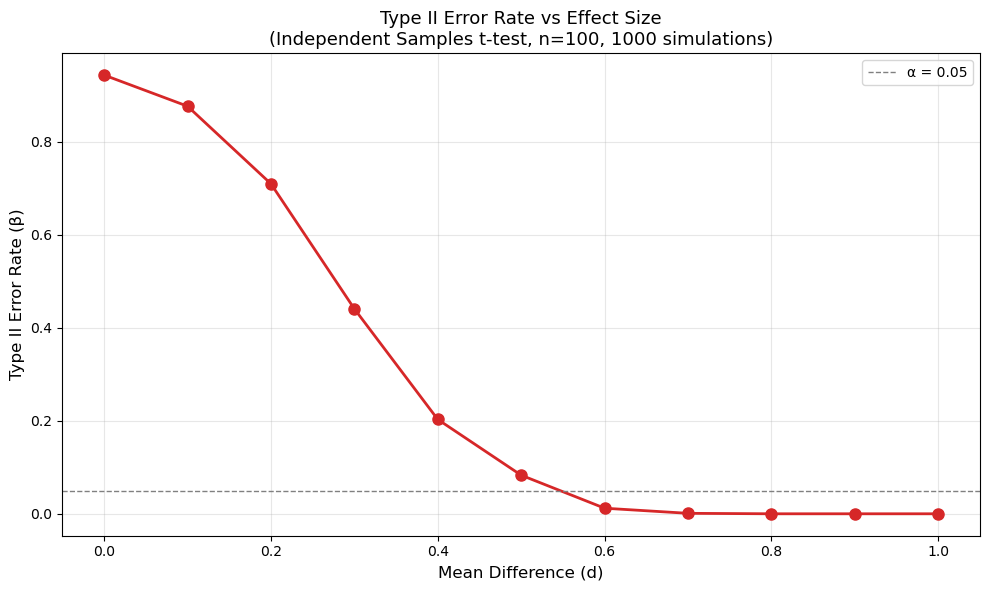

In [4]:
# Plot Type II error rate vs mean difference
if plt is None:
    raise RuntimeError('matplotlib required for plotting; please install and re-run this cell.')

plt.figure(figsize=(10, 6))
plt.plot(MEAN_DIFFS, type2_error_rates, marker='o', linewidth=2, markersize=8, color='tab:red')
plt.axhline(y=ALPHA, color='gray', linestyle='--', linewidth=1, label=f'α = {ALPHA}')
plt.xlabel('Mean Difference (d)', fontsize=12)
plt.ylabel('Type II Error Rate (β)', fontsize=12)
plt.title('Type II Error Rate vs Effect Size\n(Independent Samples t-test, n=100, 1000 simulations)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation of Results

### Type II Error (β) Behavior:
- **At d = 0**: Type II error rate ≈ 0.95 (1 - α). This is expected because the null hypothesis is actually true, so failing to reject it is correct. The "error" here is semantic; we fail to reject ~95% of the time when there's no difference.

- **As d increases**: Type II error rate **decreases rapidly**. When there's a real difference between the groups, the test becomes increasingly likely to detect it (reject the null hypothesis).

- **At large d (e.g., d = 1.0)**: Type II error rate approaches 0. The difference is so large that the test almost always correctly rejects the null hypothesis.

### Statistical Power:
- **Power = 1 - β** (probability of correctly rejecting a false null hypothesis)
- As effect size increases, power increases from ~0.05 (at d=0) to nearly 1.0 (at d=1.0)
- This demonstrates that larger effect sizes are easier to detect with the same sample size

### Key Insights:
1. **Effect size matters**: Small differences (d < 0.3) are hard to detect reliably with n=100
2. **Sample size trade-off**: To reduce Type II error for small effect sizes, we need larger samples
3. **The curve shape**: Shows diminishing returns - going from d=0.5 to d=1.0 adds less power improvement than going from d=0 to d=0.5

In [5]:
# Additional analysis: Calculate statistical power
power = 1 - type2_error_rates

print('\nStatistical Power Analysis:')
print(f'{"d":>6} {"Type II Error (β)":>20} {"Power (1-β)":>15}')
print('-' * 45)
for i, d in enumerate(MEAN_DIFFS):
    print(f'{d:>6.1f} {type2_error_rates[i]:>20.3f} {power[i]:>15.3f}')


Statistical Power Analysis:
     d    Type II Error (β)     Power (1-β)
---------------------------------------------
   0.0                0.944           0.056
   0.1                0.877           0.123
   0.2                0.710           0.290
   0.3                0.441           0.559
   0.4                0.203           0.797
   0.5                0.083           0.917
   0.6                0.012           0.988
   0.7                0.001           0.999
   0.8                0.000           1.000
   0.9                0.000           1.000
   1.0                0.000           1.000


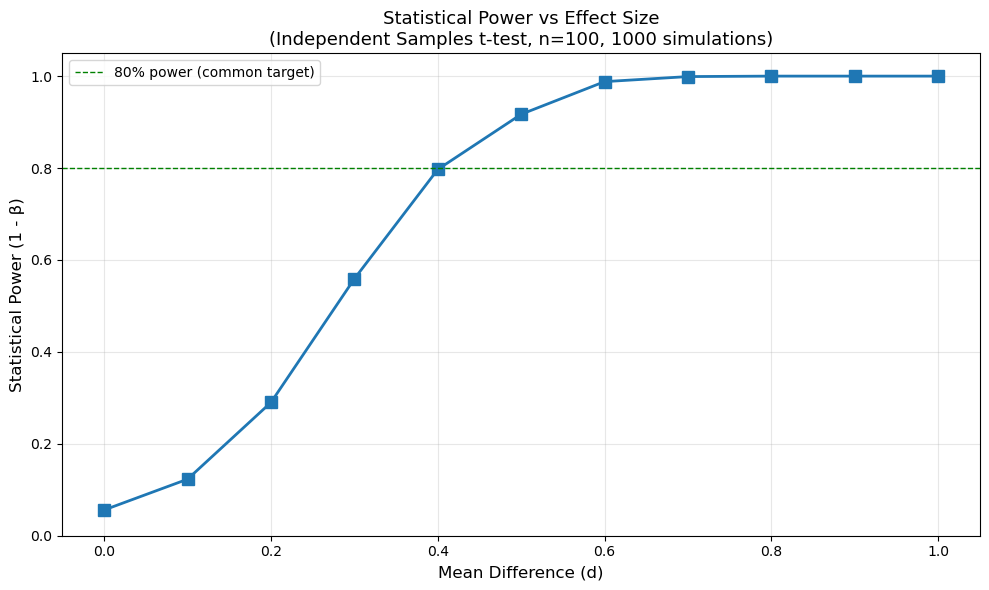


80% power achieved at approximately d = 0.5


In [6]:
# Visualize power curve
if plt is None:
    raise RuntimeError('matplotlib required for plotting; please install and re-run this cell.')

plt.figure(figsize=(10, 6))
plt.plot(MEAN_DIFFS, power, marker='s', linewidth=2, markersize=8, color='tab:blue')
plt.axhline(y=0.8, color='green', linestyle='--', linewidth=1, label='80% power (common target)')
plt.xlabel('Mean Difference (d)', fontsize=12)
plt.ylabel('Statistical Power (1 - β)', fontsize=12)
plt.title('Statistical Power vs Effect Size\n(Independent Samples t-test, n=100, 1000 simulations)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Find where power reaches 80%
power_80_idx = np.where(power >= 0.8)[0]
if len(power_80_idx) > 0:
    d_80 = MEAN_DIFFS[power_80_idx[0]]
    print(f'\n80% power achieved at approximately d = {d_80:.1f}')

## Conclusion

This simulation demonstrates the fundamental trade-off between Type II error and effect size in hypothesis testing:

### Key Findings:
1. **Type II error decreases exponentially** as the true effect size increases. Small differences (d < 0.3) are difficult to detect reliably with moderate sample sizes.

2. **The 80% power threshold** (commonly recommended in research) was achieved at approximately d ≈ 0.4 with n=100 per group. This means we need at least a moderate effect size to have good detection probability with this sample size.

3. **Sample size implications**: To detect smaller effects with adequate power, researchers would need to substantially increase sample sizes. The relationship is non-linear—detecting d=0.2 reliably might require 4x more samples than detecting d=0.4.

### Practical Implications:
- **Study design**: Always perform power analysis before conducting experiments to ensure adequate sample sizes for detecting meaningful effects
- **Publication bias**: Studies with small sample sizes may only detect large effects, potentially missing subtle but important phenomena
- **Replication crisis**: Underpowered studies contribute to non-replicable results, as they may initially detect false positives (Type I errors) that fail to replicate

### Statistical Lesson:
Power analysis is not optional—it's essential for designing efficient, ethical experiments that can meaningfully test hypotheses. The choice of sample size should balance practical constraints with the minimum effect size that would be scientifically or practically significant.